# Benchmark Plotting Notebook

This notebook parses a Google Benchmark-style output file that may contain non-CSV header text before the CSV header line, then plots:

- Mean **real_time** vs **N** with stddev error bars
- Mean **items_per_second** vs **N** with stddev error bars (if present)

It prefers `_mean` and `_stddev` rows when available; otherwise it computes stats from raw repeated runs.


In [27]:
from __future__ import annotations

import io
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


    commit     n  real_time_mean  real_time_std  ips_mean   ips_std time_unit
0  3f0929a   200        0.384438       0.003506  521877.0  3580.700        ms
1  3f0929a   500        1.308440       0.007981  382999.0  2348.420        ms
2  3f0929a  1000        2.810950       0.046025  357011.0  4736.140        ms
3  3f0929a  2000        5.983750       0.131887  338337.0  1442.410        ms
4  450dc0d   200        1.136510       0.047628  178373.0  4872.730        ms
5  450dc0d   500        7.025390       0.289701   71564.4  2847.690        ms
6  450dc0d  1000       29.362800       1.765920   34649.9  2495.670        ms
7  450dc0d  2000      107.163000       3.210480   18763.8   566.667        ms


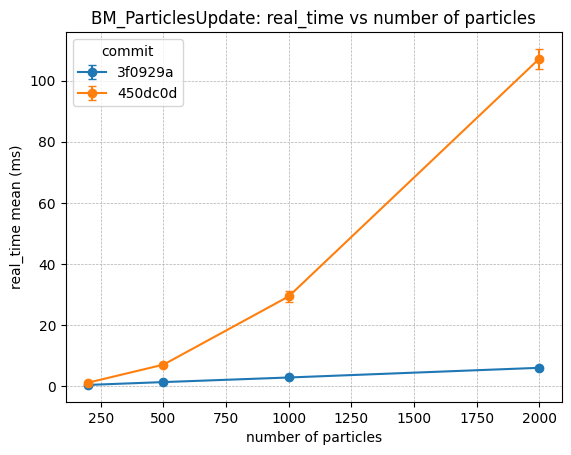

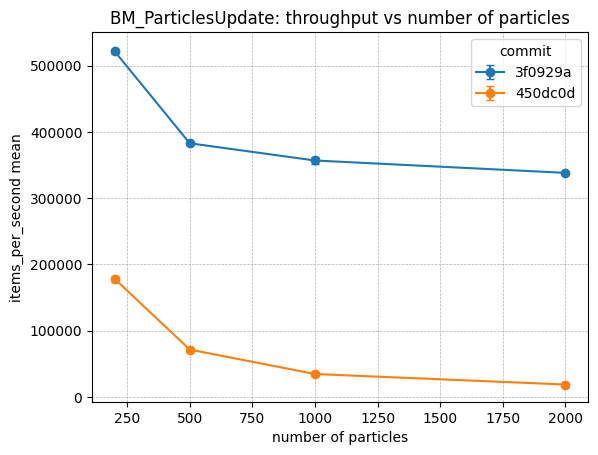

In [34]:
from __future__ import annotations

import io
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DATA_DIR = Path("data")
BENCH_BASE = "BM_ParticlesUpdate"
CSV_HEADER = "name,iterations,real_time,cpu_time,time_unit,bytes_per_second,items_per_second,label,error_occurred,error_message"

_name_re = re.compile(r"^(?P<base>.+?)/(?P<n>\d+)(?P<suffix>_(mean|median|stddev|cv))?$")
_file_re = re.compile(r"^bench_(?P<hash>[0-9a-fA-F]+)\.csv$")


def extract_csv_block(text: str) -> str:
    """Return the CSV portion starting at the known header line."""
    idx = text.find(CSV_HEADER)
    if idx < 0:
        raise ValueError("Could not find CSV header line in the input.")
    return text[idx:]


def split_name(name: str):
    """Parse 'BM_ParticlesUpdate/200_mean' -> (base, n, suffix)."""
    m = _name_re.match(str(name).strip().strip('"'))
    if not m:
        return None, None, None
    base = m.group("base")
    n = int(m.group("n"))
    suffix = m.group("suffix")  # None, '_mean', '_stddev', ...
    return base, n, suffix


def to_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def build_stats(df: pd.DataFrame, base_filter: str) -> pd.DataFrame:
    """Build stats table: n, real_time_mean, real_time_std, ips_mean, ips_std."""
    parsed = df["name"].astype(str).apply(split_name)
    df = df.copy()
    df["base"] = parsed.apply(lambda t: t[0])
    df["n"] = parsed.apply(lambda t: t[1])
    df["suffix"] = parsed.apply(lambda t: t[2])

    df = df[df["base"] == base_filter].copy()
    df = to_numeric(df, ["real_time", "items_per_second"])

    time_unit_vals = df["time_unit"].dropna().astype(str).unique()
    time_unit = time_unit_vals[0] if len(time_unit_vals) else "time_unit"

    have_mean = (df["suffix"] == "_mean").any()
    have_std = (df["suffix"] == "_stddev").any()

    rows = []
    for n, g in df.groupby("n"):
        entry = {"n": int(n), "time_unit": time_unit}

        if have_mean:
            mean_row = g[g["suffix"] == "_mean"]
            entry["real_time_mean"] = float(mean_row["real_time"].iloc[0]) if len(mean_row) else np.nan
            entry["ips_mean"] = float(mean_row["items_per_second"].iloc[0]) if len(mean_row) else np.nan
        else:
            raw = g[g["suffix"].isna()]
            entry["real_time_mean"] = float(raw["real_time"].mean()) if len(raw) else np.nan
            entry["ips_mean"] = float(raw["items_per_second"].mean()) if len(raw) else np.nan

        if have_std:
            std_row = g[g["suffix"] == "_stddev"]
            entry["real_time_std"] = float(std_row["real_time"].iloc[0]) if len(std_row) else np.nan
            entry["ips_std"] = float(std_row["items_per_second"].iloc[0]) if len(std_row) else np.nan
        else:
            raw = g[g["suffix"].isna()]
            entry["real_time_std"] = float(raw["real_time"].std(ddof=1)) if len(raw) > 1 else 0.0
            entry["ips_std"] = float(raw["items_per_second"].std(ddof=1)) if len(raw) > 1 else 0.0

        rows.append(entry)

    return pd.DataFrame(rows).sort_values("n").reset_index(drop=True)


def load_bench_csv(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8", errors="replace")
    csv_text = extract_csv_block(text)
    return pd.read_csv(io.StringIO(csv_text))


def commit_hash_from_filename(path: Path) -> str:
    m = _file_re.match(path.name)
    return m.group("hash") if m else path.stem  # fallback


def load_all_stats(data_dir: Path, base_filter: str) -> list[tuple[str, pd.DataFrame]]:
    """Return list of (label, stats_df) for each bench_*.csv found."""
    out: list[tuple[str, pd.DataFrame]] = []
    for p in sorted(data_dir.glob("bench_*.csv")):
        label = commit_hash_from_filename(p)
        try:
            df = load_bench_csv(p)
            stats = build_stats(df, base_filter=base_filter)
            if len(stats):
                out.append((label, stats))
            else:
                print(f"[skip] {p.name}: no rows for base '{base_filter}'")
        except Exception as e:
            print(f"[skip] {p.name}: {e}")
    return out


def plot_stats_multi(all_stats: list[tuple[str, pd.DataFrame]], base_filter: str, log_axes: bool = True) -> None:
    if not all_stats:
        raise ValueError("No benchmark CSVs produced stats (check folder / base name).")

    # Choose a unit for the y label (use the first non-empty)
    unit = "time"
    for _, st in all_stats:
        if "time_unit" in st.columns and len(st) and pd.notna(st["time_unit"].iloc[0]):
            unit = str(st["time_unit"].iloc[0])
            break

    # Plot 1: time
    plt.figure()
    for label, st in all_stats:
        n = st["n"].to_numpy()
        plt.errorbar(
            n,
            st["real_time_mean"],
            yerr=st["real_time_std"],
            marker="o",
            capsize=3,
            label=label,
        )
    if log_axes:
        plt.xscale("log")
        plt.yscale("log")
    plt.xlabel("number of particles")
    plt.ylabel(f"real_time mean ({unit})")
    plt.title(f"{base_filter}: real_time vs number of particles")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(title="commit")
    plt.show()

    # Plot 2: items/s
    any_ips = any(st["ips_mean"].notna().any() for _, st in all_stats)
    if any_ips:
        plt.figure()
        for label, st in all_stats:
            if not st["ips_mean"].notna().any():
                continue
            n = st["n"].to_numpy()
            plt.errorbar(
                n,
                st["ips_mean"],
                yerr=st["ips_std"],
                marker="o",
                capsize=3,
                label=label,
            )
        if log_axes:
            plt.xscale("log")
            plt.yscale("log")
        plt.xlabel("number of particles")
        plt.ylabel("items_per_second mean")
        plt.title(f"{base_filter}: throughput vs number of particles")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5)
        plt.legend(title="commit")
        plt.show()


# --- Run ---
all_stats = load_all_stats(DATA_DIR, base_filter=BENCH_BASE)

# Optional: inspect combined table
combined = pd.concat(
    [st.assign(commit=label) for label, st in all_stats],
    ignore_index=True
)
combined = combined[["commit", "n", "real_time_mean", "real_time_std", "ips_mean", "ips_std", "time_unit"]]
print(combined)

plot_stats_multi(all_stats, base_filter=BENCH_BASE, log_axes=False)